In [20]:
import pandas as pd
from pathlib import Path
import numpy as np
import string
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, spearmanr
from scipy.signal import lombscargle

In [2]:
path = Path("data/dgdreq2025nov21_JB.csv")
df = pd.read_csv(path)
df.shape, df.columns.tolist()

((45858, 6),
 ['source_id',
  'lensComponentSourceId',
  'flux_obs',
  'flux_obs_error',
  'isFluxCalibrated',
  'epoch_obs_jd'])

In [3]:
df["source_id"] = pd.to_numeric(df["source_id"], errors="coerce").astype("Int64")
df["lensComponentSourceId"] = pd.to_numeric(df["lensComponentSourceId"], errors="coerce").astype("Int64")
df["epoch_obs_jd"] = pd.to_numeric(df["epoch_obs_jd"], errors="coerce")
df["flux_obs"] = pd.to_numeric(df["flux_obs"], errors="coerce")
df["flux_obs_error"] = pd.to_numeric(df["flux_obs_error"], errors="coerce")

df = df.dropna(subset=["source_id", "lensComponentSourceId", "epoch_obs_jd"]).copy()
df = df.sort_values(["source_id", "lensComponentSourceId", "epoch_obs_jd"]).reset_index(drop=True)

data_by_source = {
    int(source_id): {
        int(comp_id): g_comp[["epoch_obs_jd", "flux_obs", "flux_obs_error", "isFluxCalibrated"]].reset_index(drop=True)
        for comp_id, g_comp in g_source.groupby("lensComponentSourceId", sort=False)
    }
    for source_id, g_source in df.groupby("source_id", sort=False)
}

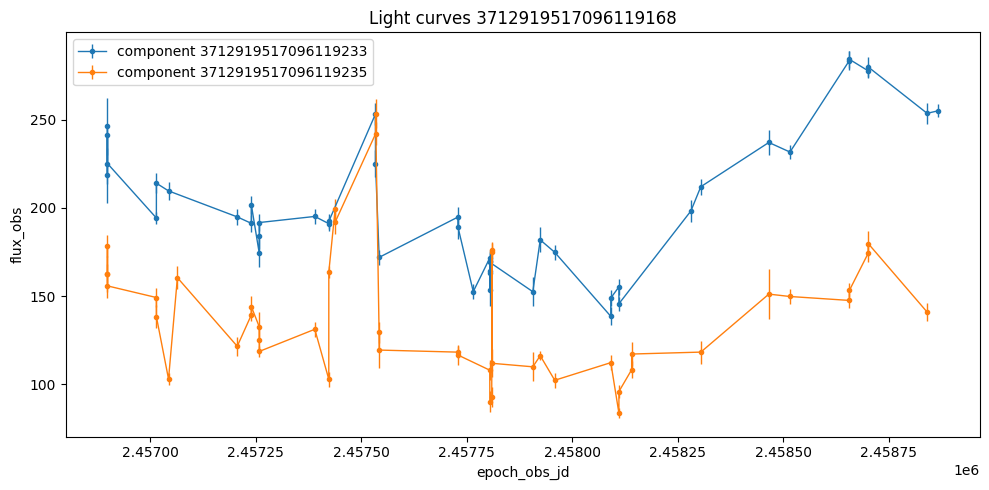

(3712919517096119168,
 <IntegerArray>
 [3712919517096119233, 3712919517096119235]
 Length: 2, dtype: Int64)

In [4]:
counts = df.groupby("source_id")["lensComponentSourceId"].nunique().sort_values(ascending=False)
two_comp_sources = counts[counts == 2].index.tolist()
example_source_id = int(two_comp_sources[124]) if two_comp_sources else int(counts.index[0])
sub = df[df["source_id"] == example_source_id].copy()
sub = sub.sort_values(["lensComponentSourceId","epoch_obs_jd"])

plt.figure(figsize=(10, 5))
for comp_id, g in sub.groupby("lensComponentSourceId"):
    g = g.sort_values("epoch_obs_jd")
    plt.errorbar(
        g["epoch_obs_jd"], g["flux_obs"], yerr=g["flux_obs_error"],
        fmt="o-", markersize=3, linewidth=1,
        label=f"component {int(comp_id)}"
    )

plt.xlabel("epoch_obs_jd")
plt.ylabel("flux_obs")
plt.title(f"Light curves {example_source_id}")
plt.legend()
plt.tight_layout()
plt.show()

example_source_id, sub["lensComponentSourceId"].unique()

In [7]:
#Id des Lentilles connues lentille_ids = []
lentille_ids = [5077935264216200832,
 2216740927658907648,
 1910735807875873664,
 2623596445097415040,
 395754921063313024,
 380075812236197760,
 2348420123825646336,
 2373803788569100160,
 4999447421238071936,
 2369490546185699328,
 2355800355108946432,
 2371361983695995264,
 2804295954148390272,
 2358531232755701504,
 2531819311878644096,
 4915503625466318464,
 372057559265314688,
 2533897461870477568,
 322056271561143680,
 291933776127888768,
 2561983348235519360,
 318810027903595392,
 2457482365811994368,
 2464353660650971520,
 2460545948804796032,
 350937280929196928,
 4954121596274054400,
 4960819894125714944,
 5026013408869280128,
 4955044292688756224,
 5024429528010102144,
 4956574748452174592,
 5148785186464567168,
 4956634220861679360,
 76904623545392512,
 4971233295737205760,
 4964421000864875904,
 5124658637175794048,
 4643616493228910080,
 337933769222851840,
 2515417110948750976,
 5119328548401927936,
 5119104866505106688,
 5184007624848431872,
 5174409201871203584,
 549281756875772672,
 5075630859644356480,
 5174520836660663296,
 83871575896093312,
 114294031844958720,
 5153686358329651840,
 5153828508862119040,
 5098921578230761472,
 3261414236903292160,
 4674636224510336256,
 5085135764002995584,
 63971411866955904,
 4672765852152430848,
 5087747928752251776,
 4834883855209175296,
 4683151559814721920,
 5082980996090316800,
 4842045799074927232,
 4845606606136183424,
 4883180423150691584,
 4830236636170244480,
 4779902849277205760,
 4778637895508914048,
 175720825910626304,
 3178020716638059264,
 3185808420059318016,
 4894145268500809728,
 4877987734675447936,
 4624301922220808832,
 3187010529866092672,
 4813484648808076544,
 4770993403477832064,
 2959785663027256832,
 2959142032112859264,
 4826116113268202112,
 4807486087029366784,
 196343055547397888,
 2903556569666059648,
 2966721824756464896,
 2903331715240526592,
 5571267199383508096,
 2916884609097868672,
 960989934527118848,
 1116767058322038656,
 5261791097486778624,
 3000185396729743104,
 1103603357219723904,
 3385786701564912384,
 2933340793481678208,
 3361094865862486656,
 986525370526178176,
 5585883698943303296,
 871794729486078336,
 672293537240480768,
 3138952727746236800,
 867913659598182272,
 3164374261215669888,
 925907232901783296,
 921013100488801920,
 670520540382618496,
 5694395291770945280,
 3097346657995436800,
 649514817411198976,
 679072919780579200,
 1097468636388676608,
 3092314541167221760,
 3080259323881652608,
 5643847512428416384,
 5641500188236488704,
 1016218227493362816,
 607381016436338560,
 712654684950723072,
 3842934499335828608,
 1043171896055716608,
 580537092879961472,
 1022663637669586176,
 698878899471973120,
 695593902327484544,
 817452844753700736,
 3844748070752040576,
 817592276569391488,
 5691734916002651136,
 1026420252290292480,
 3851608129957910400,
 641511742854886144,
 613773504026183808,
 621369175165121408,
 797882950824323584,
 807714470266431488,
 646884373280519936,
 5672017928032611840,
 5687124801186026880,
 3832692033126977664,
 1045166002126206720,
 827031141513223936,
 806853178999388928,
 3834882054131088512,
 3876832198007366912,
 5666444778469974656,
 730552393494441856,
 3552950883176150016,
 3817878828362669568,
 3541826024524572544,
 1537658249711963904,
 6159550763996866944,
 3941492797505654784,
 3511426761399556352,
 3733119018870073216,
 1475457506834977280,
 1469230594530741760,
 3711531005707407104,
 3728132222538228864,
 1454504418686043904,
 1599341745383363328]

In [8]:
lentille_set = set(int(x) for x in lentille_ids)
#1 si c'est une lentille 0 sinon
df["is_lens"] = df["source_id"].astype("int64").isin(lentille_set).astype("int8")

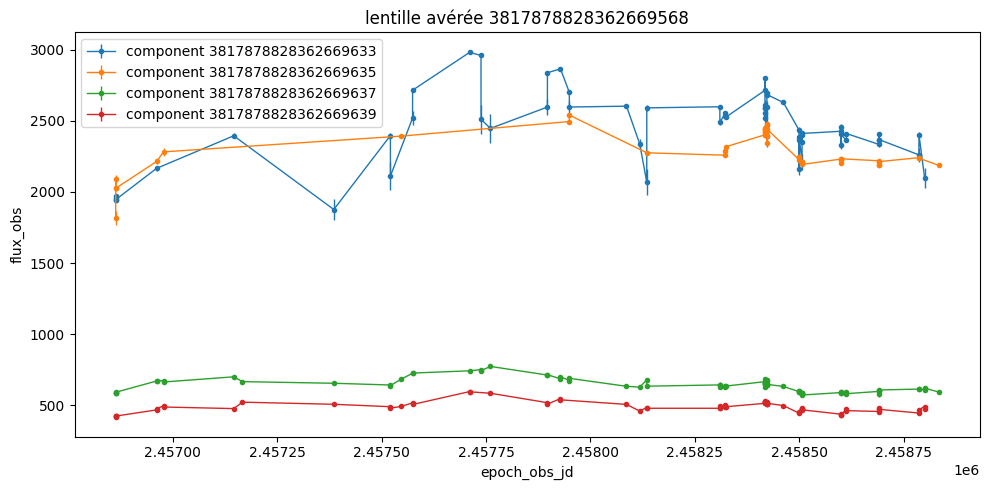

source_id = 3817878828362669568
components = <IntegerArray>
[3817878828362669633, 3817878828362669635, 3817878828362669637,
 3817878828362669639]
Length: 4, dtype: Int64


In [19]:
df_lens = df[df["is_lens"] == 1].copy()
stats = (
    df_lens.groupby("source_id")
    .agg(n_comp=("lensComponentSourceId", "nunique"),
         n_obs=("epoch_obs_jd", "size"))
)

candidates = stats[stats["n_comp"] >= 2].sort_values(["n_obs", "n_comp"], ascending=False)
if candidates.empty:
    raise ValueError("Aucune lentille avérée avec >= 2 composantes trouvée dans df.")

example_source_id = int(candidates.index[8])

sub = df_lens[df_lens["source_id"] == example_source_id].copy()
sub = sub.sort_values(["lensComponentSourceId", "epoch_obs_jd"])

plt.figure(figsize=(10, 5))
for comp_id, g in sub.groupby("lensComponentSourceId"):
    g = g.sort_values("epoch_obs_jd")
    plt.errorbar(
        g["epoch_obs_jd"], g["flux_obs"], yerr=g["flux_obs_error"],
        fmt="o-", markersize=3, linewidth=1,
        label=f"component {int(comp_id)}"
    )

plt.xlabel("epoch_obs_jd")
plt.ylabel("flux_obs")
plt.title(f"lentille avérée {example_source_id}")
plt.legend()
plt.tight_layout()
plt.show()

print("source_id =", example_source_id)
print("components =", sub["lensComponentSourceId"].dropna().unique())

In [13]:
def add_relative_magnitude(df, flux_col="flux_obs", err_col="flux_obs_error", ct_obs=25.6233):
    '''Take an obs flux and spit out the same data but in mag relative
    '''
    df = df.copy()
    msk = df[flux_col].notna() & (df[flux_col] > 0) & df[err_col].notna() & (df[err_col] > 0)
    df = df[msk].copy()

    df["mag_obs"] = -2.5 * np.log10(df[flux_col].astype(float)) + ct_obs
    df["mag_obs_error"] = (2.5 / np.log(10)) * (df[err_col].astype(float) / df[flux_col].astype(float))
    return df

In [14]:
def wmean(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    return np.sum(w * x) / np.sum(w)

def align_components_on_common_mean(
    df,
    source_col="source_id",
    comp_col="lensComponentSourceId",
    value_col="mag_obs",
    err_col="mag_obs_error",
    out_shift_col="baseline_shift",
    out_value_col="mag_aligned",
):
    """
    Ajoute deux colonnes:
      - out_shift_col : décalage appliqué à chaque composante d'une même source
      - out_value_col : valeur alignée (value_col + shift)
    Sans modifier les lignes, l'index, ni l'ordre du DataFrame d'entrée.
    """
    out = df.copy()

    # poids
    w = 1.0 / (out[err_col].astype(float) ** 2)
    out["_w_tmp"] = w

    # moyenne pondérée par (source, composante)
    # mu_sc = sum(w*y)/sum(w)
    grp_sc = out.groupby([source_col, comp_col], sort=False)
    sum_wy = grp_sc.apply(lambda g: np.sum(g["_w_tmp"] * g[value_col].astype(float)))
    sum_w  = grp_sc["_w_tmp"].sum()
    mu_sc = (sum_wy / sum_w).rename("mu_sc")  # MultiIndex (source, comp)

    # moyenne de référence par source = moyenne des moyennes de composantes
    mu_ref = mu_sc.groupby(level=0).mean().rename("mu_ref")  # index=source

    # shift par (source, comp) : mu_ref(source) - mu_sc(source, comp)
    shift_sc = (mu_ref.reindex(mu_sc.index.get_level_values(0)).to_numpy() - mu_sc.to_numpy())
    shift_sc = pd.Series(shift_sc, index=mu_sc.index, name=out_shift_col)

    # mapper le shift sur chaque ligne (source, comp)
    keys = list(zip(out[source_col].astype("Int64"), out[comp_col].astype("Int64")))
    out[out_shift_col] = pd.Index(keys).map(shift_sc)

    # valeur alignée
    out[out_value_col] = out[value_col].astype(float) + out[out_shift_col].astype(float)

    # nettoyage
    out.drop(columns=["_w_tmp"], inplace=True)

    return out

In [15]:
df = add_relative_magnitude(df)
df = align_components_on_common_mean(df)
df

,source_id,lensComponentSourceId,flux_obs,flux_obs_error,isFluxCalibrated,epoch_obs_jd,is_lens,mag_obs,mag_obs_error,baseline_shift,mag_aligned
0,63971411866955904,63971411866955969,546.930227,12.096125,0,2.456907e+06,1,18.778470,0.024013,0.135106,18.913576
1,63971411866955904,63971411866955969,546.816246,9.297076,0,2.457028e+06,1,18.778696,0.018460,0.135106,18.913802
2,63971411866955904,63971411866955969,548.703230,7.708399,0,2.457038e+06,1,18.774956,0.015253,0.135106,18.910062
3,63971411866955904,63971411866955969,547.692598,6.074010,0,2.457038e+06,1,18.776958,0.012041,0.135106,18.912063
4,63971411866955904,63971411866955969,530.256199,5.971939,0,2.457214e+06,1,18.812086,0.012228,0.135106,18.947191
...,...,...,...,...,...,...,...,...,...,...,...
45853,6914637621299597824,6914637621299597891,114.302710,5.067627,0,2.458639e+06,0,20.478159,0.048136,-0.382326,20.095833
45854,6914637621299597824,6914637621299597891,138.657642,5.720094,0,2.458774e+06,0,20.268440,0.044790,-0.382326,19.886115
45855,6914637621299597824,6914637621299597891,134.182718,5.207567,0,2.458803e+06,0,20.304059,0.042137,-0.382326,19.921733
45856,6914637621299597824,6914637621299597891,134.129779,6.416503,0,2.458803e+06,0,20.304487,0.051939,-0.382326,19.922161


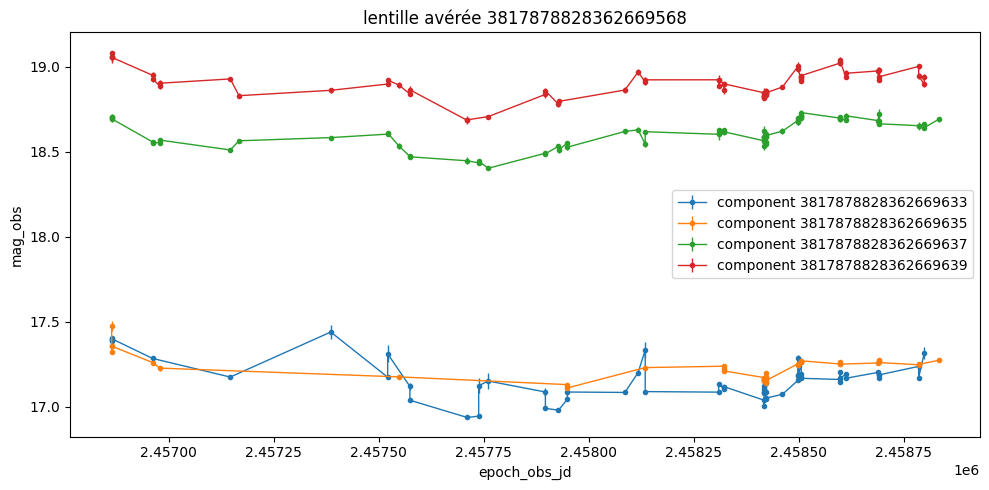

source_id = 3817878828362669568
components = <IntegerArray>
[3817878828362669633, 3817878828362669635, 3817878828362669637,
 3817878828362669639]
Length: 4, dtype: Int64


In [18]:
df_lens = df[df["is_lens"] == 1].copy()
stats = (
    df_lens.groupby("source_id")
    .agg(n_comp=("lensComponentSourceId", "nunique"),
         n_obs=("epoch_obs_jd", "size"))
)

candidates = stats[stats["n_comp"] >= 2].sort_values(["n_obs", "n_comp"], ascending=False)
if candidates.empty:
    raise ValueError("Aucune lentille avérée avec >= 2 composantes trouvée dans df.")

example_source_id = int(candidates.index[8])

sub = df_lens[df_lens["source_id"] == example_source_id].copy()
sub = sub.sort_values(["lensComponentSourceId", "epoch_obs_jd"])

plt.figure(figsize=(10, 5))
for comp_id, g in sub.groupby("lensComponentSourceId"):
    g = g.sort_values("epoch_obs_jd")
    plt.errorbar(
        g["epoch_obs_jd"], g["mag_obs"], yerr=g["mag_obs_error"],
        fmt="o-", markersize=3, linewidth=1,
        label=f"component {int(comp_id)}"
    )

plt.xlabel("epoch_obs_jd")
plt.ylabel("mag_obs")
plt.title(f"lentille avérée {example_source_id}")
plt.legend()
plt.tight_layout()
plt.show()

print("source_id =", example_source_id)
print("components =", sub["lensComponentSourceId"].dropna().unique())

In [29]:
def wmean(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if m.sum() == 0:
        return np.nan
    return np.sum(w[m] * x[m]) / np.sum(w[m])

def wvar(x, w, ddof=0):
    """Variance pondérée (type 'population' si ddof=0)."""
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if m.sum() <= 1:
        return np.nan
    mu = np.sum(w[m] * x[m]) / np.sum(w[m])
    v = np.sum(w[m] * (x[m] - mu) ** 2) / np.sum(w[m])
    # correction ddof simple (optionnelle)
    if ddof != 0:
        v = v * (m.sum() / max(1, (m.sum() - ddof)))
    return v

def intrinsic_var(x, xerr):
    """
    Variance "intrinsèque" très simple : Var(obs) - mean(err^2).
    Idée: si la courbe est dominée par le bruit de mesure, cette quantité ~ 0.
    """
    x = np.asarray(x, float)
    xerr = np.asarray(xerr, float)
    m = np.isfinite(x) & np.isfinite(xerr)
    if m.sum() <= 1:
        return np.nan
    v_obs = np.var(x[m], ddof=1)
    v_noise = np.mean((xerr[m]) ** 2)
    return max(0.0, v_obs - v_noise)

# ---------- hétéroscédasticité ----------
def heteroscedasticity_metrics(t, x, xerr):
    """
    L'hétéroscédasticité = variance/erreur qui change avec le niveau du signal ou le temps.
    Ici on calcule des métriques simples (robustes et rapides) :
      1) CV des erreurs (std/mean) : si >> 0, erreur très variable
      2) corrélation (Spearman) entre flux et err : typique en photométrie (objets faibles => plus d'erreur)
      3) corrélation entre resid^2 et err^2 : si fort, la dispersion observée est pilotée par le bruit de mesure
    """
    t = np.asarray(t, float)
    x = np.asarray(x, float)
    xerr = np.asarray(xerr, float)
    m = np.isfinite(t) & np.isfinite(x) & np.isfinite(xerr) & (xerr > 0)
    if m.sum() < 5:
        return dict(het_err_cv=np.nan, het_flux_err_spearman=np.nan, het_resid_err_spearman=np.nan)

    err = xerr[m]
    het_err_cv = np.std(err) / np.mean(err)

    # corr monotone (robuste aux non-linéarités)
    rho_flux_err, _ = spearmanr(x[m], err)

    # résidus par rapport à une moyenne pondérée (baseline ultra simple)
    w = 1.0 / (err ** 2)
    mu = wmean(x[m], w)
    resid = x[m] - mu
    rho_resid_err, _ = spearmanr(resid**2, err**2)

    return dict(
        het_err_cv=float(het_err_cv),
        het_flux_err_spearman=float(rho_flux_err),
        het_resid_err_spearman=float(rho_resid_err),
    )

def compute_lightcurve_stats(df, value_col="mag_obs", err_col="mag_obs_error", time_col="epoch_obs_jd",
                            source_col="source_id", comp_col="lensComponentSourceId"):
    """
    Une 'courbe' = (source_id, lensComponentSourceId).
    On calcule variance, variance intrinsèque, kurtosis + hétéroscédasticité.
    """
    rows = []
    for (sid, cid), g in df.groupby([source_col, comp_col]):
        t = g[time_col].to_numpy()
        x = g[value_col].to_numpy()
        xe = g[err_col].to_numpy()

        w = np.where(np.isfinite(xe) & (xe > 0), 1.0 / (xe ** 2), np.nan)
        v_w = wvar(x, w, ddof=0)
        v_unw = np.var(x[np.isfinite(x)], ddof=1) if np.isfinite(x).sum() > 1 else np.nan
        v_int = intrinsic_var(x, xe)

        k = kurtosis(x[np.isfinite(x)], fisher=True, bias=False) if np.isfinite(x).sum() > 3 else np.nan

        het = heteroscedasticity_metrics(t, x, xe)

        rows.append({
            source_col: sid,
            comp_col: cid,
            "n_pts": int(np.isfinite(x).sum()),
            "t_span_days": float(np.nanmax(t) - np.nanmin(t)) if np.isfinite(t).sum() > 1 else np.nan,
            "var_unweighted": float(v_unw),
            "var_weighted": float(v_w),
            "var_intrinsic": float(v_int),
            "kurtosis_fisher": float(k),
            **het
        })

    return pd.DataFrame(rows)



stats_df = compute_lightcurve_stats(df)
display(stats_df)

mean_var_all = stats_df["var_intrinsic"].mean(skipna=True)
print("Variance intrinsèque moyenne (toutes courbes):", mean_var_all)

# 2) Variance moyenne des courbes 'lentilles'
# Ici: on considère "lentille" si une source a >= 2 composantes
ncomp = stats_df.groupby("source_id")["lensComponentSourceId"].nunique()
lens_sources = set(ncomp[ncomp >= 2].index)
mean_var_lenses = stats_df.loc[stats_df["source_id"].isin(lens_sources), "var_intrinsic"].mean(skipna=True)
print("Variance intrinsèque moyenne (sources avec >=2 composantes):", mean_var_lenses)

,source_id,lensComponentSourceId,n_pts,t_span_days,var_unweighted,var_weighted,var_intrinsic,kurtosis_fisher,het_err_cv,het_flux_err_spearman,het_resid_err_spearman
0,63971411866955904,63971411866955969,37,1854.007231,0.067273,0.042240,0.066920,-0.145118,0.293190,0.030820,0.428639
1,63971411866955904,63971411866955971,21,1838.917174,0.062098,0.044996,0.061736,-1.287469,0.310362,0.296104,0.454545
2,76904623545392512,76904623545392577,48,1962.246961,0.000811,0.000729,0.000319,1.725876,0.299701,0.436062,0.095636
3,76904623545392512,76904623545392579,10,1197.907636,0.048610,0.058306,0.039590,0.023574,0.231734,0.418182,-0.187879
4,76904623545392512,76904623545392581,3,902.959679,0.036324,0.014374,0.025964,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
908,6896655868835640192,6896655868835640261,20,1501.570536,0.020035,0.015899,0.017265,-0.591506,0.390704,0.103759,0.130827
909,6897592820245635328,6897592820245635393,48,1841.786098,0.012036,0.009290,0.011366,0.190679,0.331026,0.291142,0.245115
910,6897592820245635328,6897592820245635395,8,1075.792011,0.003684,0.002636,0.000000,-1.604202,0.356825,-0.238095,0.142857
911,6914637621299597824,6914637621299597889,60,1836.284165,0.001616,0.001170,0.001102,0.998584,0.401200,-0.041901,0.211003


Variance intrinsèque moyenne (toutes courbes): 0.023568948050960648
Variance intrinsèque moyenne (sources avec >=2 composantes): 0.022949983882204865


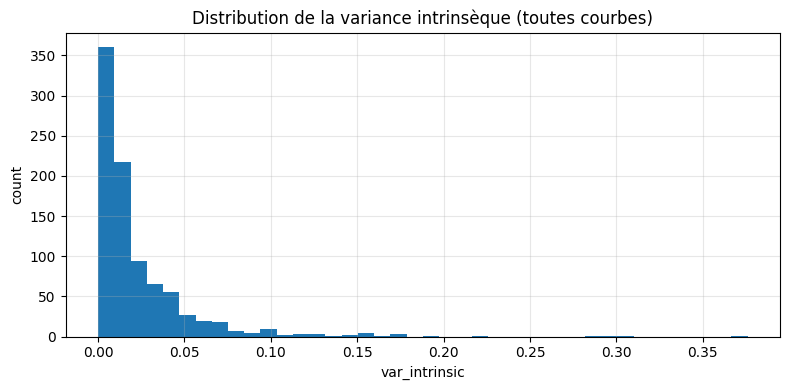

C:\Users\tpichard\AppData\Local\Temp\ipykernel_18244\1598793520.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([x_non, x_lens], labels=["non-lens", "lens"], showfliers=False)


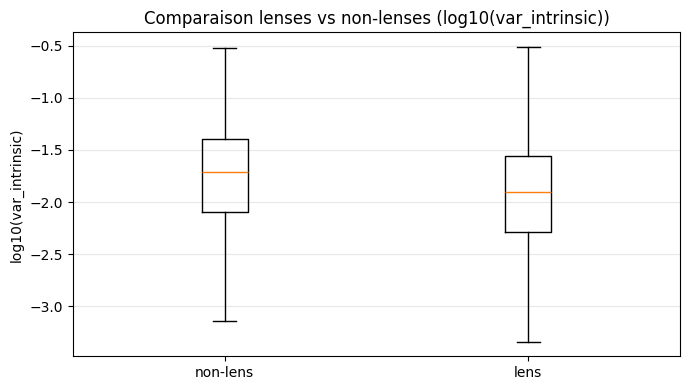

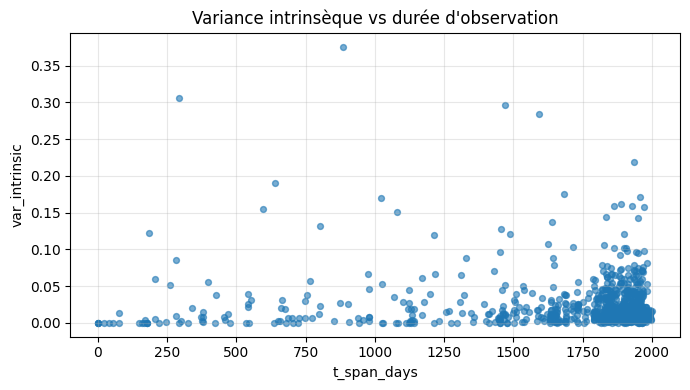

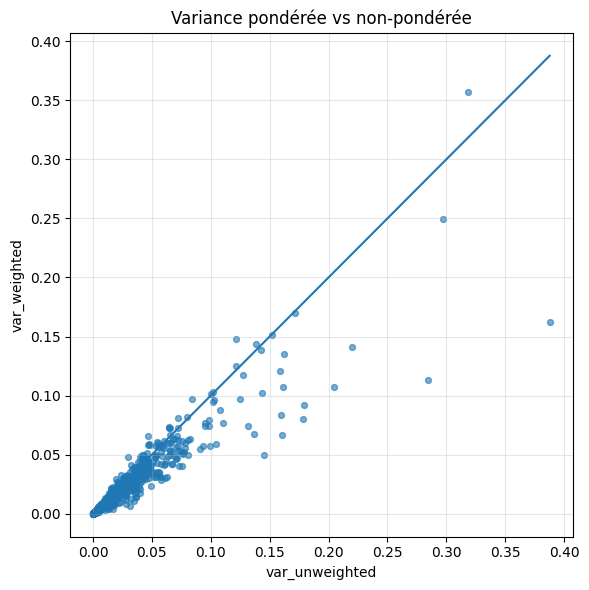

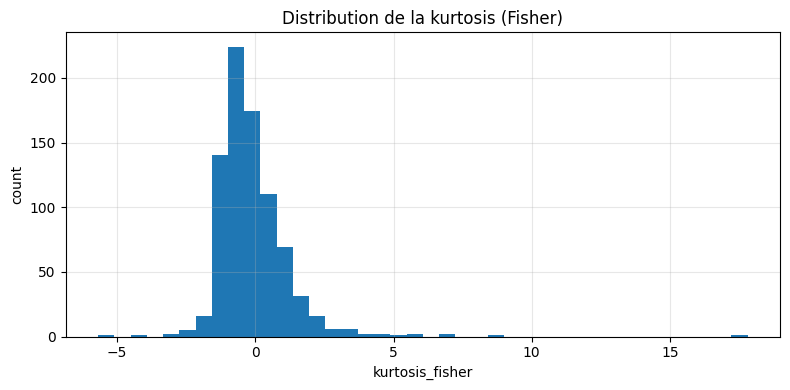

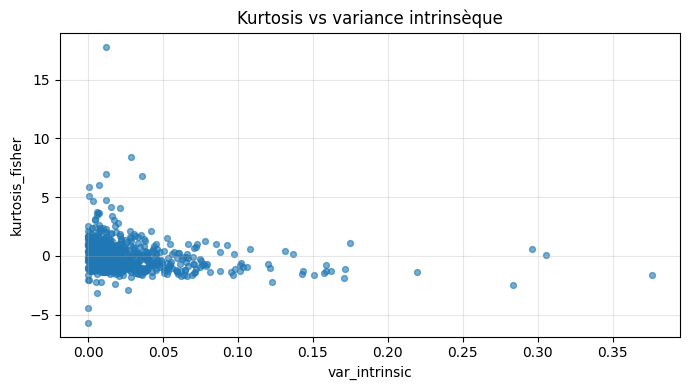

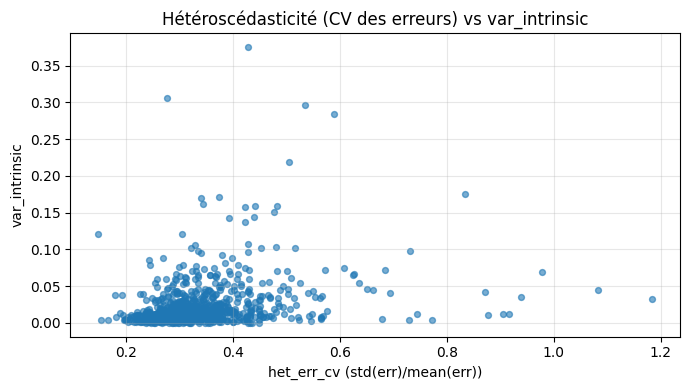

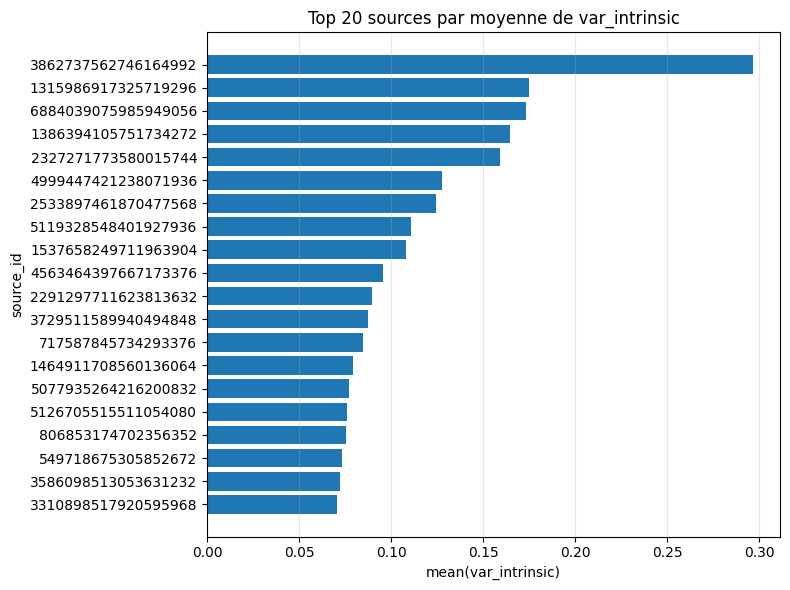

Moyenne sans valeurs extrêmes : -0.2142480256911814


In [48]:

# --- Prépare un flag "lens" : source avec >= 2 composantes ---
ncomp = stats_df.groupby("source_id")["lensComponentSourceId"].nunique()
lens_sources = set(ncomp[ncomp >= 2].index)
stats_df = stats_df.copy()
stats_df["is_lens"] = stats_df["source_id"].isin(lens_sources)

# Petite utilité pour log sans crash (var peut être 0)
EPS = 1e-12
stats_df["log_var_intrinsic"] = np.log10(stats_df["var_intrinsic"].to_numpy() + EPS)

# =========================
# 1) Distribution var_intrinsic (hist)
# =========================
x_all = stats_df["var_intrinsic"].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
plt.figure(figsize=(8, 4))
plt.hist(x_all, bins=40)
plt.title("Distribution de la variance intrinsèque (toutes courbes)")
plt.xlabel("var_intrinsic")
plt.ylabel("count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 2) Lenses vs non-lenses : boxplot sur log(var_intrinsic)
# =========================
x_lens = stats_df.loc[stats_df["is_lens"], "log_var_intrinsic"].dropna().to_numpy()
x_non  = stats_df.loc[~stats_df["is_lens"], "log_var_intrinsic"].dropna().to_numpy()

plt.figure(figsize=(7, 4))
plt.boxplot([x_non, x_lens], labels=["non-lens", "lens"], showfliers=False)
plt.title("Comparaison lenses vs non-lenses (log10(var_intrinsic))")
plt.ylabel("log10(var_intrinsic)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 3) var_intrinsic vs t_span_days (scatter)
# =========================
tmp = stats_df[["t_span_days", "var_intrinsic", "is_lens"]].replace([np.inf, -np.inf], np.nan).dropna()
plt.figure(figsize=(7, 4))
plt.scatter(tmp["t_span_days"], tmp["var_intrinsic"], s=18, alpha=0.6)
plt.title("Variance intrinsèque vs durée d'observation")
plt.xlabel("t_span_days")
plt.ylabel("var_intrinsic")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 4) var_weighted vs var_unweighted + y=x
# =========================
tmp = stats_df[["var_unweighted", "var_weighted"]].replace([np.inf, -np.inf], np.nan).dropna()
plt.figure(figsize=(6, 6))
plt.scatter(tmp["var_unweighted"], tmp["var_weighted"], s=18, alpha=0.6)
m = np.nanmax(np.r_[tmp["var_unweighted"].to_numpy(), tmp["var_weighted"].to_numpy()])
plt.plot([0, m], [0, m])
plt.title("Variance pondérée vs non-pondérée")
plt.xlabel("var_unweighted")
plt.ylabel("var_weighted")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 5) Kurtosis (hist) + relation kurtosis vs var_intrinsic
# =========================
k = stats_df["kurtosis_fisher"].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
plt.figure(figsize=(8, 4))
plt.hist(k, bins=40)
plt.title("Distribution de la kurtosis (Fisher)")
plt.xlabel("kurtosis_fisher")
plt.ylabel("count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

tmp = stats_df[["kurtosis_fisher", "var_intrinsic"]].replace([np.inf, -np.inf], np.nan).dropna()
plt.figure(figsize=(7, 4))
plt.scatter(tmp["var_intrinsic"], tmp["kurtosis_fisher"], s=18, alpha=0.6)
plt.title("Kurtosis vs variance intrinsèque")
plt.xlabel("var_intrinsic")
plt.ylabel("kurtosis_fisher")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 6) Hétéroscédasticité : het_err_cv vs var_intrinsic
# =========================
tmp = stats_df[["het_err_cv", "var_intrinsic"]].replace([np.inf, -np.inf], np.nan).dropna()
plt.figure(figsize=(7, 4))
plt.scatter(tmp["het_err_cv"], tmp["var_intrinsic"], s=18, alpha=0.6)
plt.title("Hétéroscédasticité (CV des erreurs) vs var_intrinsic")
plt.xlabel("het_err_cv (std(err)/mean(err))")
plt.ylabel("var_intrinsic")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 7) Top sources : moyenne var_intrinsic par source (barh)
# =========================
per_source = (stats_df.groupby("source_id")["var_intrinsic"]
              .mean()
              .replace([np.inf, -np.inf], np.nan)
              .dropna()
              .sort_values(ascending=False))

topN = 20
top = per_source.head(topN).iloc[::-1]  # reverse pour barh
plt.figure(figsize=(8, 6))
plt.barh([str(s) for s in top.index], top.values)
plt.title(f"Top {topN} sources par moyenne de var_intrinsic")
plt.xlabel("mean(var_intrinsic)")
plt.ylabel("source_id")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

col = stats_df["kurtosis_fisher"]
filtered = col[(col > col.quantile(0.05)) & (col < col.quantile(0.95))]
print(f"Moyenne sans valeurs extrêmes : {filtered.mean()}")

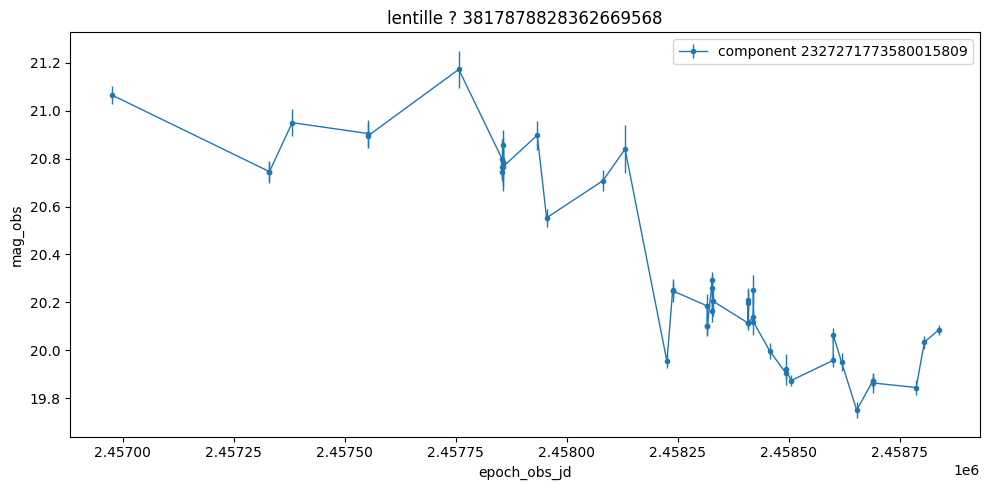

source_id = 3817878828362669568
components = <IntegerArray>
[2327271773580015809]
Length: 1, dtype: Int64


In [42]:
Dic= [
    3862737562746164992,
    1315986917325719296,
    6884039075985949056,
    1386394105751734272,
    2327271773580015744
]

sub = df[df["source_id"] == Dic[1]].copy()
sub = sub.sort_values(["lensComponentSourceId", "epoch_obs_jd"])

plt.figure(figsize=(10, 5))
for comp_id, g in sub.groupby("lensComponentSourceId"):
    g = g.sort_values("epoch_obs_jd")
    plt.errorbar(
        g["epoch_obs_jd"], g["mag_obs"], yerr=g["mag_obs_error"],
        fmt="o-", markersize=3, linewidth=1,
        label=f"component {int(comp_id)}"
    )

plt.xlabel("epoch_obs_jd")
plt.ylabel("mag_obs")
plt.title(f"lentille ? {example_source_id}")
plt.legend()
plt.tight_layout()
plt.show()

print("source_id =", example_source_id)
print("components =", sub["lensComponentSourceId"].dropna().unique())